## Import Libraries

In [325]:
import numpy as np
import csv
import matplotlib.pyplot as plt
import seaborn as sns

# scikit
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.linear_model import RidgeClassifier, RidgeClassifierCV, RidgeCV
from sklearn.model_selection import cross_val_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC

## Import Data, separate data, end as Xtr, Ytr, Xte, Yte

### import data

In [326]:
with open("/Users/jadeg/Documents/UW/winter/AMATH 582/HW5/Weather_Data.csv", 'r') as x:
    weather_data_list = list(csv.reader(x, delimiter=","))

weather_data_str = np.empty((8760, 16), dtype=object)
weather_labels = weather_data_list[2]
for row_i in range(3,len(weather_data_list)):
    weather_data_str[row_i-3,:] = weather_data_list[row_i]

weather_data = float_arr = weather_data_str.astype(float)

# convert celsius to fathrenheit
print(weather_labels)
temp_i = 5

print(weather_data[:,temp_i])
weather_data[:,temp_i] = (weather_data[:,temp_i]*1.8)+32
print(weather_data[:,temp_i])

['Year', 'Month', 'Day', 'Hour', 'Minute', 'Temperature', 'AOD', 'Cloud Type', 'DHI', 'DNI', 'GHI', 'Ozone', 'Relative Humidity', 'Pressure', 'Wind Speed', 'Precipitable Water']
[-0.2 -0.4 -0.3 ... -0.3 -0.2  0. ]
[31.64 31.28 31.46 ... 31.46 31.64 32.  ]


### plot date vs temperature over the year

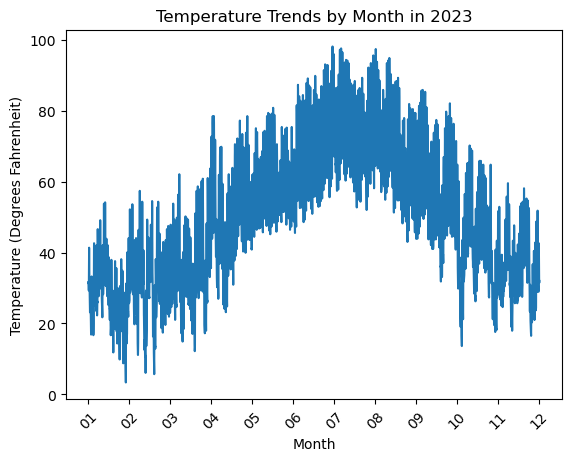

In [327]:
hr_arr = np.empty((8760,), dtype=object)
for row_i in range(len(weather_data)):
    yr = weather_data[row_i,0]
    mo = weather_data[row_i,1]
    da = weather_data[row_i,2]
    hr = weather_data[row_i,3]
    hr_arr[row_i] = f'{mo}-{da} {hr}hr'

temp_arr = weather_data[:,temp_i]

plt.figure()
plt.plot(hr_arr,temp_arr)

# Set only unique months as x-axis labels
tick_positions = np.linspace(0, len(hr_arr) - 1, 12)
plt.xticks(
    # Approx every 30 days
    ticks=tick_positions,  
    labels=['01','02','03','04','05','06','07','08','09','10','11','12'],  
    rotation=45  
)

plt.xlabel("Month")
plt.ylabel("Temperature (Degrees Fahrenheit)")
plt.title("Temperature Trends by Month in 2023")
plt.savefig('/Users/jadeg/Documents/UW/winter/AMATH 582/HW5/figures/temptrendplot.png')
plt.show()

### look at daily average temps

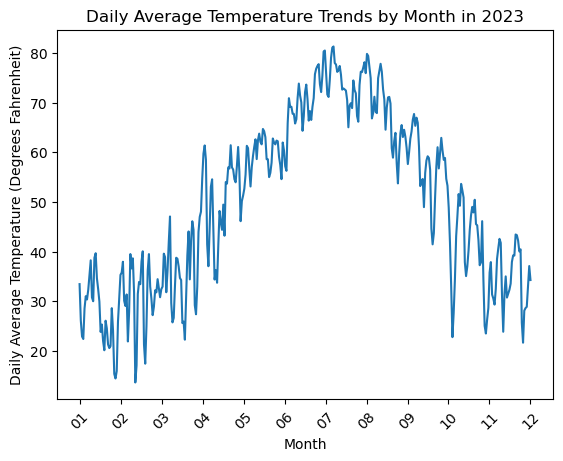

In [328]:
date_arr = np.arange(0,365,1)
daily_avg_arr = np.zeros(365)
for i in range(365):
    daily_avg = np.mean(temp_arr[i*24:(i+1)*24])
    daily_avg_arr[i] = daily_avg

plt.figure()
plt.plot(date_arr,daily_avg_arr)

# Set only unique months as x-axis labels
tick_positions = np.linspace(0, len(date_arr) - 1, 12)
plt.xticks(
    # Approx every 30 days
    ticks=tick_positions,  
    labels=['01','02','03','04','05','06','07','08','09','10','11','12'],  
    rotation=45  
)

plt.xlabel("Month")
plt.ylabel("Daily Average Temperature (Degrees Fahrenheit)")
plt.title("Daily Average Temperature Trends by Month in 2023")
plt.savefig('/Users/jadeg/Documents/UW/winter/AMATH 582/HW5/figures/dailyavg_temptrendplot.png')
plt.show()
    

### separate data

In [329]:

X = weather_data[:,temp_i+1:]
Y = weather_data[:,temp_i]

Xtr, Xte, Ytr, Yte = train_test_split(X, Y, test_size=0.2)

# change the shapes to have features as rows, samples as columns
Xtr = Xtr.T
Xte = Xte.T

print(f'Xtr {Xtr.shape}')
print(f'Ytr {Ytr.shape}')
print(f'Xte {Xte.shape}')
print(f'Yte {Yte.shape}')

Xtr (10, 7008)
Ytr (7008,)
Xte (10, 1752)
Yte (1752,)


## Define Variables - sizes

In [330]:
X_features = 10
Y_features = 1
tr_samps = 7008
te_samps = 1752

## Apply Full PCA

In [331]:
pca = PCA()
Xtr_pca = pca.fit_transform(Xtr.T)
print(Xtr_pca.shape)

(7008, 10)


## Examine Cum Energy and Determine K Needed for 85%

1


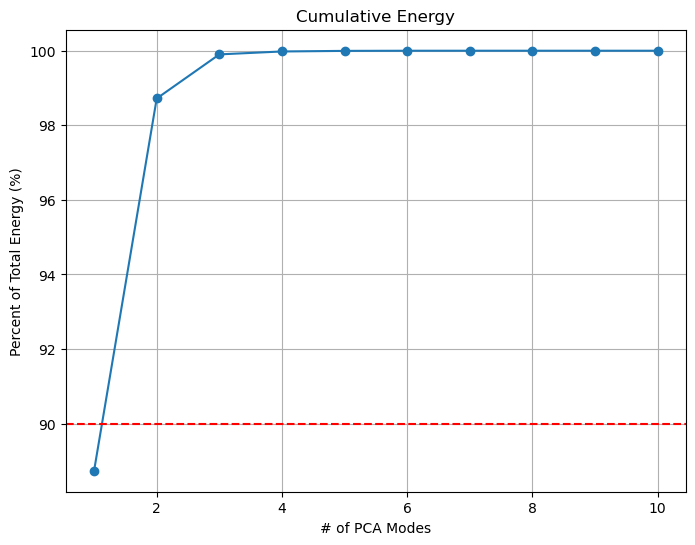

In [332]:
# pull out singular values to calculate norm^2
S = pca.singular_values_
norm_full = (np.sum(S**2))

# plot the cumulative energy of K=1:num_feats (784)
x = np.arange(1,X_features+1)
y = np.zeros(X_features)
j = 0

# initialize K_85, once the energy passes 85% then save that K value as K_85
K_85 = 0
for K in x:
    S_n = S[0:K]
    norm_approx = (np.sum(S_n**2)) 
    y[j] = (norm_approx/norm_full) * 100
    if y[j] >= 85:
        if K_85==0:
            K_85 = K
    j+= 1
print(K_85)

# plot cumulative energy
plt.figure(figsize=(8,6))

plt.plot(x,y,'o-')
plt.grid()

# add lines are percents in problem statement
percs = [90]
for perc in percs:
    plt.axhline(y=perc, color='r', linestyle='--')

plt.xlabel('# of PCA Modes')
plt.ylabel('Percent of Total Energy (%)')
plt.title('Cumulative Energy')
plt.savefig('/Users/jadeg/Documents/UW/winter/AMATH 582/HW5/figures/CumEnergy.png')

In [242]:
K85 = K_85
K = 3

## Use Ridge Classification wtih Xtr and Ytr

In [333]:
alphas = np.logspace(-3, 0, 100)
num_trials = 5
RidgeTr_score_array = np.zeros(num_trials)
RidgeTe_score_array = np.zeros(num_trials)

# make ridge classifier and fit
RidgeCL = RidgeCV(alphas=alphas)

# refit PCA model 
pca_K = PCA(n_components=K)
Xtr_pca_K = pca_K.fit_transform(Xtr.T)
print(type(Xtr_pca_K))
print(type(Ytr))
RidgeCL.fit(Xtr_pca_K, Ytr)

# use ridge classifier score as a check for training
ridgescore_tr = (RidgeCL.score(Xtr_pca_K, Ytr))*100
print(f'The score of the training set is {ridgescore_tr}')

# project data onto K-PC (59) modes
Xte_pca_K = pca_K.transform(Xte.T)

# use ridge classifier score as a check for testing
ridgescore_te = (RidgeCL.score(Xte_pca_K, Yte))*100
print(f'The score of the testing set is {ridgescore_te}')

'''# add train and test scores to an array
RidgeTr_score_array[trial] = ridgescore_tr
RidgeTe_score_array[trial] = ridgescore_te'''

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
The score of the training set is 88.85852683459197
The score of the testing set is 89.02844184912887


'# add train and test scores to an array\nRidgeTr_score_array[trial] = ridgescore_tr\nRidgeTe_score_array[trial] = ridgescore_te'

## Try putting temperatures into categories to then classify

In [334]:
# try every 5 degrees
# 0: 0-5, 1: 5-10, 2: 10-15, 3: 15-20, 4: 20-25, 5: 25-30, 6: 30-35, 7: 35-40, 8: 40-45, 9: 45-50, 10: 50-55, 11: 55-60, 12: 60-65, 13: 65-70
# 14: 70-75, 15: 75-80, 16: 80-85, 17: 85-90, 18: 90-95, 19: 95-100

# take Ytr, for every temperature, assign it a category depending on the temperature 
# for every value in Ytr, for 0 to 19, if between (categorynum*5) to ((categorynum+1)*5), then replace that index in Ytr with categorynum

# try making the range adjustable
split = 5
num_cats = int(100/split)
Ytr_cat = np.zeros(len(Ytr))
cat_range = np.arange(0,num_cats,1)
cat_labs = np.array([])
for catnum in cat_range:
    lab = f'{catnum*split}-{((catnum+1)*split)}'
    cat_labs = np.append(cat_labs,lab)
    
for i,temp in enumerate(Ytr,0):
    for catnum in cat_range:
        if (temp >= (catnum*split)) and (temp < ((catnum+1)*split)):
            Ytr_cat[i] = catnum
print(cat_labs)

# repeat for Yte
Yte_cat = np.zeros(len(Yte))
for i,temp in enumerate(Yte,0):
    for catnum in cat_range:
        if (temp >= (catnum*split)) and (temp < ((catnum+1)*split)):
            Yte_cat[i] = catnum

['0-5' '5-10' '10-15' '15-20' '20-25' '25-30' '30-35' '35-40' '40-45'
 '45-50' '50-55' '55-60' '60-65' '65-70' '70-75' '75-80' '80-85' '85-90'
 '90-95' '95-100']


### Use ridge classification now with X and categorized 

## Plot 2D modes

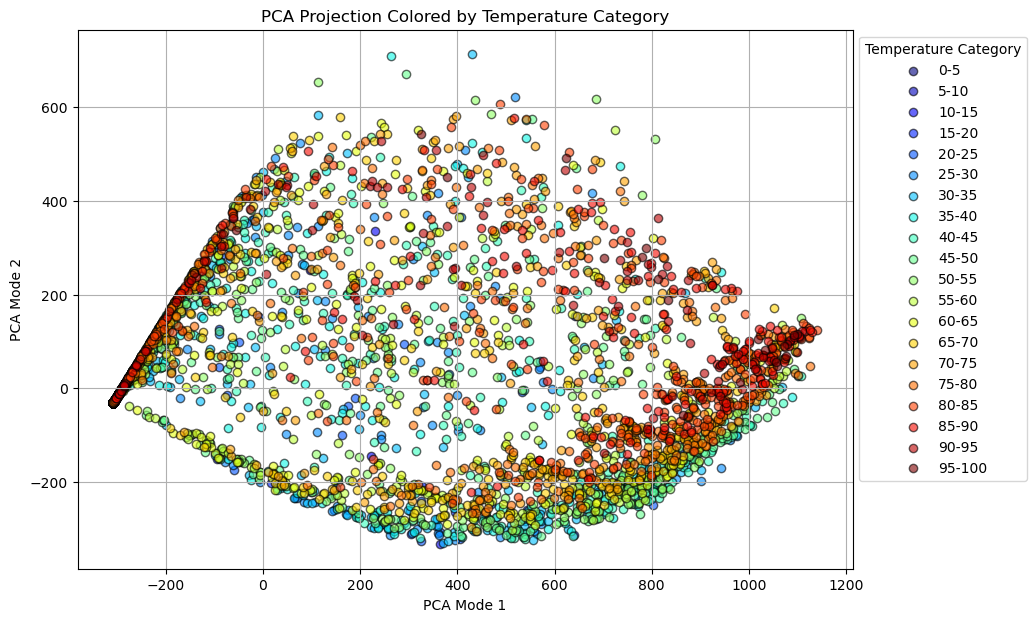

In [312]:
# Choose two PCA modes to plot
mode_x, mode_y = 0, 1  

# Perform PCA
pca = PCA(n_components=2)  
Xtr_pca = pca.fit_transform(Xtr.T)  

# Define color mapping for temperature categories
# Get unique category labels, assign colors
categories = np.unique(Ytr_cat)  
colors = plt.cm.jet(np.linspace(0, 1, len(categories))) 

# Create a scatter plot
plt.figure(figsize=(10, 7))

for i, cat in enumerate(categories):
    # Filter data points belonging to category 'cat'
    mask = (Ytr_cat == cat)  
    plt.scatter(Xtr_pca[mask, mode_x], Xtr_pca[mask, mode_y], 
                color=colors[i], label=cat_labs[i], alpha=0.6, edgecolor='k')

plt.xlabel(f"PCA Mode {mode_x + 1}")
plt.ylabel(f"PCA Mode {mode_y + 1}")
plt.title("PCA Projection Colored by Temperature Category")
plt.legend(title="Temperature Category",bbox_to_anchor=(1, 1))
plt.grid(True)

plt.savefig('/Users/jadeg/Documents/UW/winter/AMATH 582/HW5/figures/2D_pcaproj.png')
plt.show()


## Plot 3D modes

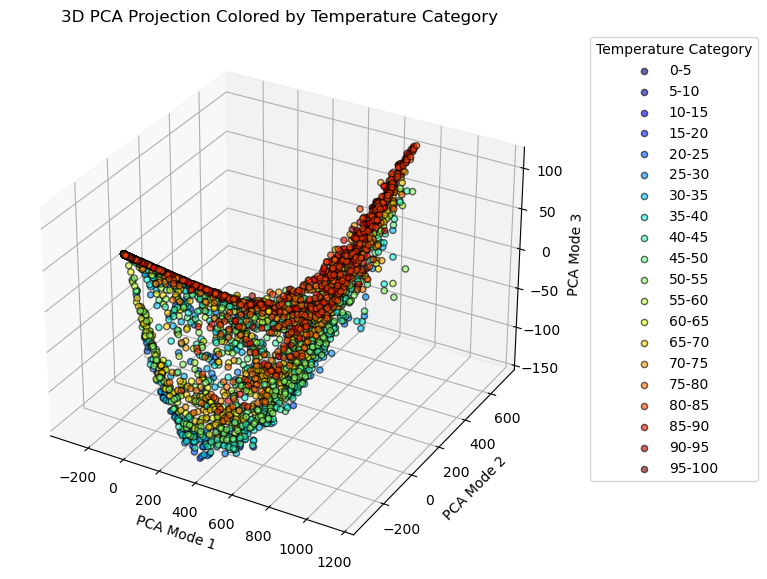

In [313]:
# Choose three PCA modes to plot
mode_x, mode_y, mode_z = 0, 1, 2 

# Perform PCA
pca = PCA(3)
Xtr_pca = pca.fit_transform(Xtr.T)  

# Define color mapping for temperature categories
categories = np.unique(Ytr_cat) 
colors = plt.cm.jet(np.linspace(0, 1, len(categories)))  

# Create a 3D scatter plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

for i, cat in enumerate(categories):
    mask = (Ytr_cat == cat) 
    ax.scatter(Xtr_pca[mask, mode_x], Xtr_pca[mask, mode_y], Xtr_pca[mask, mode_z], 
               color=colors[i], label=cat_labs[i], alpha=0.6, edgecolor='k')

ax.set_xlabel(f"PCA Mode {mode_x + 1}")
ax.set_ylabel(f"PCA Mode {mode_y + 1}")
ax.set_zlabel(f"PCA Mode {mode_z + 1}")
ax.set_title("3D PCA Projection Colored by Temperature Category")
ax.set_zlim([-150,120])
ax.legend(title="Temperature Category",bbox_to_anchor=(1.4, 1))

plt.savefig('/Users/jadeg/Documents/UW/winter/AMATH 582/HW5/figures/3D_pcaproj.png')
plt.show()


Based off this, I'm going to keep it at only 5 categories, and use 3 PCA modes to see what happens... I feel like 4 pca modes could be better but idk how to visualize that

## Do RidgeCL again

### test alpha values

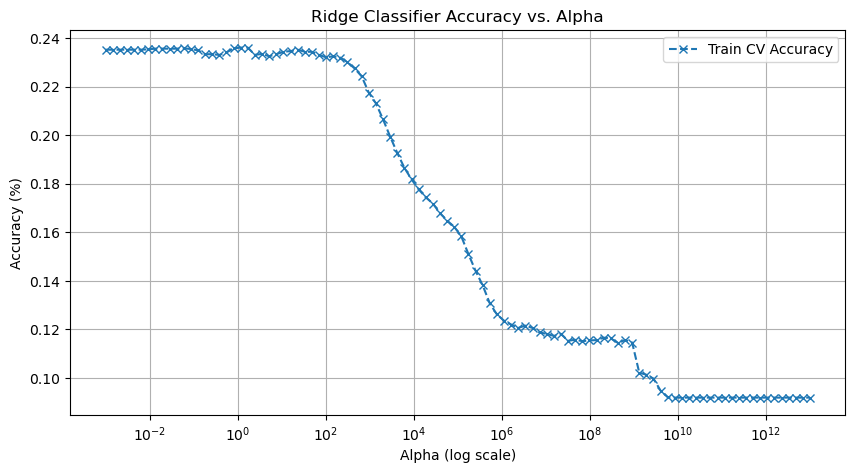

In [314]:
# Define alphas range
alphas = np.logspace(-3, 13, 100)  # Test values from 0.001 to 1000
num_trials = 5  # Number of trials (not used in this version but can be used for averaging)

# Initialize Ridge Classifier with cross-validation
RidgeCL = RidgeClassifierCV(alphas=alphas, store_cv_values=True)

# Perform PCA
pca_K = PCA(n_components=K)
Xtr_pca_K = pca_K.fit_transform(Xtr.T)  # Transform training data
Xte_pca_K = pca_K.transform(Xte.T)  # Transform test data

# Fit Ridge Classifier
RidgeCL.fit(Xtr_pca_K, Ytr_cat)

# Get training and testing scores for each alpha
train_scores = []
test_scores = []
scorescv_arr = []

for alpha in alphas:
    RidgeCL.set_params(alphas=[alpha])  # Update alpha value
    RidgeCL.fit(Xtr_pca_K, Ytr_cat)  # Refit the model

    # Compute accuracy
    train_acc = RidgeCL.score(Xtr_pca_K, Ytr_cat) * 100  # Training accuracy
    test_acc = RidgeCL.score(Xte_pca_K, Yte_cat) * 100  # Testing accuracy

    train_scores.append(train_acc)
    test_scores.append(test_acc)

    scorescv = cross_val_score(RidgeCL, Xtr_pca_K, Ytr_cat,cv=2)
    RTr_CVscoremean = scorescv.mean()
    RTr_CVscorestd = scorescv.std()
    scorescv_arr.append(RTr_CVscoremean)

# Plot accuracy vs. alpha
plt.figure(figsize=(10, 5))
#plt.plot(alphas, train_scores, label="Training Accuracy", marker='o')
#plt.plot(alphas, test_scores, label="Testing Accuracy", marker='s', linestyle='dashed')
plt.plot(alphas, scorescv_arr, label="Train CV Accuracy", marker='x', linestyle='dashed')

plt.xscale('log')  # Log scale for alpha
plt.xlabel("Alpha (log scale)")
plt.ylabel("Accuracy (%)")
plt.title("Ridge Classifier Accuracy vs. Alpha")
plt.legend()
plt.grid(True)
plt.savefig(f'/Users/jadeg/Documents/UW/winter/AMATH 582/HW5/figures/RCLalphatest_split5.png')
plt.show()

### repeat Ridge CL now

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
The score of the training set is 12.32876712328767
Cross validation score is 12.014840182648403 with an std of 0.3424657534246575
The score of the training set is 11.187214611872145


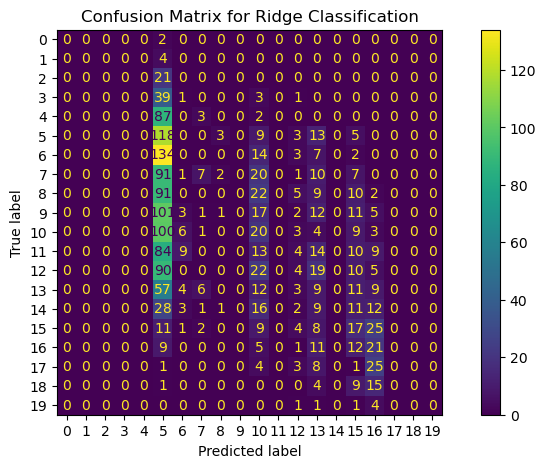

In [ ]:
alphas = np.logspace(4, 6, 100)
num_trials = 5

# make ridge classifier and fit
RidgeCL = RidgeClassifierCV(alphas=alphas)

# refit PCA model 
pca_K = PCA(n_components=K)
Xtr_pca_K = pca_K.fit_transform(Xtr.T)
print(type(Xtr_pca_K))
print(type(Ytr))
RidgeCL.fit(Xtr_pca_K, Ytr_cat)

# use ridge classifier score as a check for training
ridgescore_tr = (RidgeCL.score(Xtr_pca_K, Ytr_cat))*100
print(f'The score of the training set is {ridgescore_tr}')

scorescv = cross_val_score(RidgeCL, Xtr_pca_K, Ytr_cat,cv=2)
RTr_CVscoremean = (scorescv.mean())*100
RTr_CVscorestd = (scorescv.std())*100
print(f'Cross validation score is {RTr_CVscoremean} with an std of {RTr_CVscorestd}')

# project data onto K-PC (59) modes
Xte_pca_K = pca_K.transform(Xte.T)


# use ridge classifier score as a check for testing
ridgescore_te = (RidgeCL.score(Xte_pca_K, Yte_cat))*100
print(f'The score of the test set is {ridgescore_te}')

# make a classification matrix
Ypred = RidgeCL.predict(Xte_pca_K)

fig, ax = plt.subplots(figsize=(10, 5))
ConfusionMatrixDisplay.from_predictions(Yte_cat, Ypred, ax=ax)
ax.set_xticks(range(len(cat_range))) 
ax.set_yticks(range(len(cat_range)))
ax.xaxis.set_ticklabels(cat_range)
ax.yaxis.set_ticklabels(cat_range)
_ = ax.set_title(
    f"Confusion Matrix for Ridge Classification"
)
plt.savefig(f'/Users/jadeg/Documents/UW/winter/AMATH 582/HW5/figures/RCLclass_confmat_split5.png')

## Use KNN with Xtr and Ytr

### test different K values

15.596461187214611 accuracy with a standard deviation of 0.24257990867579782
14.92579908675799 accuracy with a standard deviation of 0.028538812785387613
14.797374429223744 accuracy with a standard deviation of 0.2140410958904102
15.582191780821919 accuracy with a standard deviation of 0.028538812785387613
15.967465753424657 accuracy with a standard deviation of 0.07134703196347125
16.53824200913242 accuracy with a standard deviation of 0.15696347031963498
16.08162100456621 accuracy with a standard deviation of 0.35673515981735004
15.981735159817351 accuracy with a standard deviation of 0.17123287671232745
16.281392694063925 accuracy with a standard deviation of 0.2996575342465757
16.481164383561644 accuracy with a standard deviation of 0.38527397260273943
16.309931506849317 accuracy with a standard deviation of 0.49942922374429166
16.267123287671232 accuracy with a standard deviation of 0.37100456621004696
16.210045662100455 accuracy with a standard deviation of 0.057077625570777
16.2

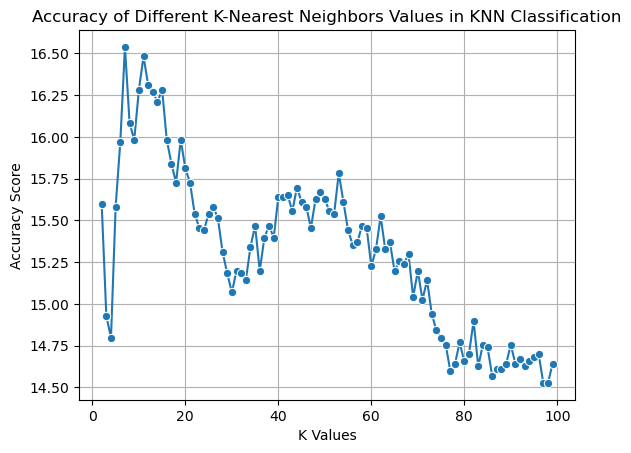

In [297]:
k_values = [i for i in range(2,100)]
scores = []

for kn in k_values:
    KNNCLk = KNeighborsClassifier(n_neighbors=kn)
    KNNCLk.fit(Xtr_pca_K, Ytr_cat)
    scorescv = (cross_val_score(KNNCLk, Xtr_pca_K, Ytr_cat,cv=2))*100
    print("{} accuracy with a standard deviation of {}".format(scorescv.mean(), scorescv.std()))
    scores.append(scorescv.mean())
k_KNN_best = np.argmax(scores)+2
print(k_KNN_best)

sns.lineplot(x = k_values, y = scores, marker = 'o')
plt.xlabel("K Values")
plt.ylabel("Accuracy Score")
plt.title("Accuracy of Different K-Nearest Neighbors Values in KNN Classification")
plt.grid()
plt.savefig("/Users/jadeg/Documents/UW/winter/AMATH 582/HW5/figures/Ktest_KNNclass_tr.png")

### run KNN with optimal K

Train score is 38.54166666666667
Test score is 17.579908675799086
Cross validation score is 16.53824200913242 with an std of 0.15696347031963487


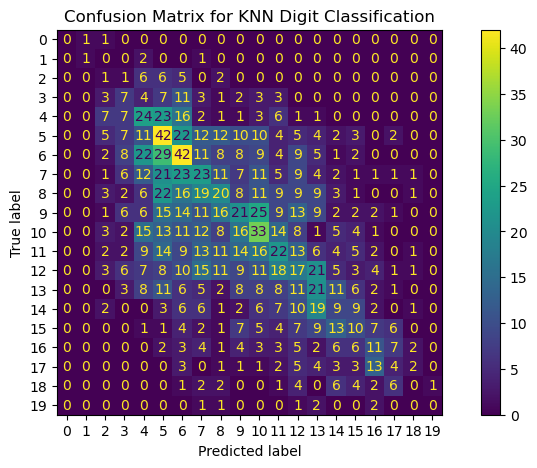

In [296]:
# use optimal K value in KNN
KNNCL = KNeighborsClassifier(n_neighbors=k_KNN_best)
KNNCL.fit(Xtr_pca_K, Ytr_cat)

KNNTr_score = (KNNCL.score(Xtr_pca_K, Ytr_cat))*100
KNNTe_score = (KNNCL.score(Xte_pca_K, Yte_cat))*100
print(f'Train score is {KNNTr_score}')
print(f'Test score is {KNNTe_score}')

scorescv = cross_val_score(KNNCL, Xtr_pca_K, Ytr_cat,cv=2)
KNNTr_CVscoremean = (scorescv.mean())*100
KNNTr_CVscorestd = (scorescv.std())*100
print(f'Cross validation score is {KNNTr_CVscoremean} with an std of {KNNTr_CVscorestd}')

Ypred_KNN = KNNCL.predict(Xte_pca_K)

fig, ax = plt.subplots(figsize=(10, 5))
ConfusionMatrixDisplay.from_predictions(Yte_cat, Ypred_KNN, ax=ax)
ax.set_xticks(range(len(cat_range))) 
ax.set_yticks(range(len(cat_range)))
ax.xaxis.set_ticklabels(cat_range)
ax.yaxis.set_ticklabels(cat_range)
_ = ax.set_title(
    f"Confusion Matrix for KNN Digit Classification"
)
plt.savefig(f'/Users/jadeg/Documents/UW/winter/AMATH 582/HW5/figures/KNNclass_confmat_split5.png')

## Use LDA with Xtr and Ytr

Train score is 12.228881278538813
Test score is 11.358447488584474


/Applications/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_split.py:725: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


CV score mean is 16.80925892550766 with std 0.43022599467137645


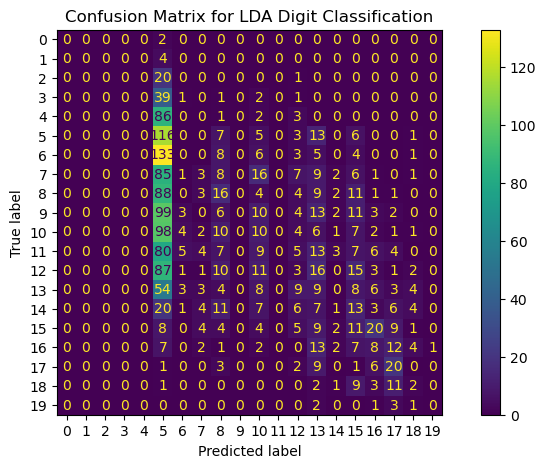

In [299]:
# apply LDA
LDACL = LinearDiscriminantAnalysis()
LDACL.fit(Xtr_pca_K, Ytr_cat)

# find accuracy score
LDATr_score = (LDACL.score(Xtr_pca_K, Ytr_cat))*100
LDATe_score = (LDACL.score(Xte_pca_K, Yte_cat))*100
print(f'Train score is {LDATr_score}')
print(f'Test score is {LDATe_score}')

# find score with cross val score
scores_tr = cross_val_score(KNNCL, Xtr_pca_K, Ytr_cat, cv=5)
LDATr_CVscoremean = (scores_tr.mean())*100
LDATr_CVscorestd = (scores_tr.std())*100
print(f'CV score mean is {LDATr_CVscoremean} with std {LDATr_CVscorestd}')

Ypred_LDA = LDACL.predict(Xte_pca_K)

fig, ax = plt.subplots(figsize=(10, 5))
ConfusionMatrixDisplay.from_predictions(Yte_cat, Ypred_LDA, ax=ax)
ax.set_xticks(range(len(cat_range))) 
ax.set_yticks(range(len(cat_range)))
ax.xaxis.set_ticklabels(cat_range)
ax.yaxis.set_ticklabels(cat_range)
_ = ax.set_title(
    f"Confusion Matrix for LDA Digit Classification"
)
plt.savefig(f'/Users/jadeg/Documents/UW/winter/AMATH 582/HW5/figures/LDAclass_confmat_split5.png')

## Use SVM

Train score is 0.14098173515981735
Test score is 0.1312785388127854
CV score mean is 0.122574200913242 with std 0.002425799086757989


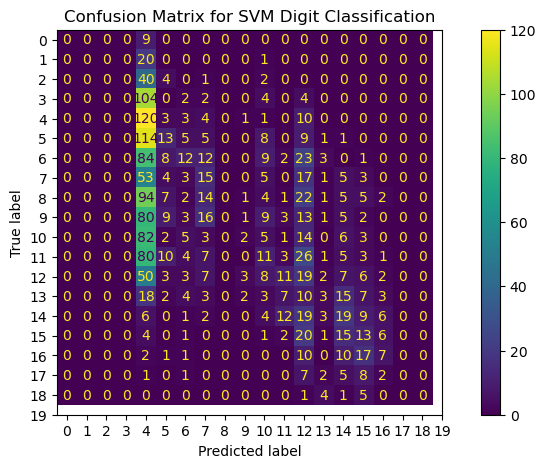

In [342]:
SVMCL = SVC()
SVMCL.fit(Xtr_pca_K, Ytr_cat)

# find accuracy score
SVMTr_score = SVMCL.score(Xtr_pca_K, Ytr_cat)
SVMTe_score = SVMCL.score(Xte_pca_K, Yte_cat)
print(f'Train score is {SVMTr_score}')
print(f'Test score is {SVMTe_score}')

# find score with cross val score
scores_tr = cross_val_score(SVMCL, Xtr_pca_K, Ytr_cat, cv=2)
SVMTr_CVscoremean = scores_tr.mean()
SVMTr_CVscorestd = scores_tr.std()
print(f'CV score mean is {SVMTr_CVscoremean} with std {SVMTr_CVscorestd}')

Ypred_SVM = SVMCL.predict(Xte_pca_K)

fig, ax = plt.subplots(figsize=(10, 5))
ConfusionMatrixDisplay.from_predictions(Yte_cat, Ypred_SVM, ax=ax)
ax.set_xticks(range(len(cat_range))) 
ax.set_yticks(range(len(cat_range)))
ax.xaxis.set_ticklabels(cat_range)
ax.yaxis.set_ticklabels(cat_range)
_ = ax.set_title(
    f"Confusion Matrix for SVM Digit Classification"
)
plt.savefig(f'/Users/jadeg/Documents/UW/winter/AMATH 582/HW5/figures/SVMclass_confmat_split5.png')

## neural network?

In [124]:
import numpy as np
import torch
from torch import nn
import tqdm

import torchvision
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
import torch.nn.init as init

from sklearn.metrics import accuracy_score

from torch.utils.data import Dataset, Subset


In [335]:
Xtr_TT = Xtr.T
Xte_TT = Xte.T

# Use the following code to create a validation set of 10%
train_indices, val_indices, _, _ = train_test_split(
    range(len(Ytr_cat)),
    Ytr_cat,
    stratify=Ytr_cat,
    test_size=0.1,
)

# Define a Custom PyTorch Dataset
class WeatherDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)  
        self.Y = torch.tensor(Y, dtype=torch.long) 

    def __len__(self):
        return len(self.Y)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

train_dataset = WeatherDataset(Xtr_TT, Ytr_cat)
test_dataset = WeatherDataset(Xte_TT, Yte_cat)

# Generate training and validation subsets based on indices
train_split = Subset(train_dataset, train_indices)
val_split = Subset(train_dataset, val_indices)

train_batch_size, val_batch_size, test_batch_size = 64,64,64

In [336]:
#Define your (As Cool As It Gets) Fully Connected Neural Network 
class ACAIGFCN(nn.Module):
    #Initialize model layers, add additional arguments to adjust
    def __init__(self, input_dim, hidden_lays, output_dim, dropout_prob, init, batchnorm): 
        super(ACAIGFCN, self).__init__()
        self.init_type = init
        #Define the network layer(s) and activation function(s)
        # create empty layers list to add layers to
        lays = []
        # set initial prev_dim as the input_dim
        prev_dim = input_dim

        # parse through each individual hidden layer, y=xAT+b
        for hidden_dim in hidden_lays:
            # apply linear transformation of input, append to layers
            lays.append(nn.Linear(prev_dim, hidden_dim))
            # apply batch norm
            if batchnorm=='yes':
                lays.append(nn.BatchNorm1d(hidden_dim))  
            # Applies theo rectified linear unit function element-wise, append to layers (introduces nonlinearlity)
            lays.append(nn.ReLU())
            # apply dropout
            lays.append(nn.Dropout(p=dropout_prob))
            # reset prev_dim as the current, hidden_dim
            prev_dim = hidden_dim
        
        # do one more linear transformation, getting to output_dim
        # no need for relu activation b/c cross entropy loss expects raw class scores
        lays.append(nn.Linear(prev_dim, output_dim))

        # sequential container - models are added to it as they are passed in constructor
        self.model = nn.Sequential(*lays) # hid,  hid2 ..

        if init=='RN' or init=='XN' or init=='KU':
            # apply initiation
            self.init_weights()
 
    def forward(self, input):
        #Define how your model propagates the input through the network
        return self.model(input)
    
    def init_weights(self):
        for layer in self.model:
            # Only initialize Linear layers
            if isinstance(layer, nn.Linear):
                if self.init_type=='RN':  
                    # Normal distribution
                    init.normal_(layer.weight, mean=0.0, std=0.01)
                elif self.init_type=='XN':
                    # Normal distribution
                    init.xavier_normal_(layer.weight) 
                elif self.init_type=='KU':
                    # Normal distribution
                    init.kaiming_uniform_(layer.weight, nonlinearity='relu')
                # Initialize bias to zero
                init.zeros_(layer.bias)  
 
    

In [337]:
# create a fxn to easily adjust parameters
def train_and_eval(input, hidden_lays, output, learning_rate, epochs, train_batch_size, opt, dropout_prob, init, batchnorm):
    # Initialize neural network model with input, output and hidden layer dimensions
    model = ACAIGFCN(input_dim = input, hidden_lays= hidden_lays, output_dim = output, dropout_prob=dropout_prob, init=init, batchnorm=batchnorm) 

    # Define dataloader objects that help to iterate over batches and samples for
    # training, validation and testing
    train_batches = DataLoader(train_split, batch_size=train_batch_size, shuffle=True)
    val_batches = DataLoader(val_split, batch_size=val_batch_size, shuffle=True)

    num_train_batches=len(train_batches)
    num_val_batches=len(val_batches)

    train_loss_list = np.zeros((epochs,))
    validation_accuracy_list = np.zeros((epochs,))

    # Define loss function  and optimizer
    # Use Cross Entropy loss from torch.nn to define loss function
    loss_func = nn.CrossEntropyLoss()

    # Use optimizers from torch.optim to define optimizer
    if opt=='SGD':
        optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    elif opt=='Adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    elif opt=='RMS':
        optimizer = torch.optim.RMSprop(model.parameters(), lr=learning_rate)

    # Iterate over epochs, batches with progress bar and train+ validate the ACAIGFCN
    # Track the loss and validation accuracy
    for epoch in tqdm.trange(epochs):
        # initialize running loss as 0
        running_loss = 0.0

        # ACAIGFCN Training 
        for train_features, train_labels in train_batches:
            # Set model into training mode
            model.train()

            # Reset gradients, 
            optimizer.zero_grad() 
            #Calculate training loss on model
            outputs = model(train_features)
            loss = loss_func(outputs, train_labels)
            # Perform optimization, back propagation
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
    
        # Record loss for the epoch by dividing sum of running loss for the epoch, dividing by length of train batches
        train_loss_list[epoch] = running_loss / num_train_batches
        
        

        val_acc_sum = 0
        # ACAIGFCN Validation
        for val_features, val_labels in val_batches:
            
            # Telling PyTorch we aren't passing inputs to network for training purpose
            with torch.no_grad(): 
                model.eval()
            
                # Compute validation outputs (targets) 
                outputs = model(val_features)  # Forward pass
                _, predicted = torch.max(outputs, 1)  # Get predicted class labels

                # add to lists
                val_acc = accuracy_score(val_labels, predicted)
                val_acc_sum += val_acc
                
                
        # Record accuracy for the epoch; print training loss, validation accuracy
        print("Epoch: "+ str(epoch) +"; Validation Accuracy:" + str(val_acc_sum/num_val_batches*100) + '%')
        validation_accuracy_list[epoch] = val_acc_sum/num_val_batches*100

    return model, train_loss_list, validation_accuracy_list



In [338]:
#Calculate accuracy on test set
def acc_test(model, test_batch_size):
    test_batches = DataLoader(test_dataset, batch_size=test_batch_size, shuffle=True)
    num_test_batches = len(test_batches)

    # Telling PyTorch we aren't passing inputs to network for training purpose
    test_labels_FCN = np.array([])
    pred_labels_FCN = np.array([])
    with torch.no_grad():
        test_acc_sum = 0
        test_acc_arr = np.array([])
        for test_features, test_labels in test_batches:

            model.eval()

            # Compute validation outputs (targets) 
            outputs = model(test_features)  # Forward pass
            _, predicted = torch.max(outputs, 1)  # Get predicted class labels
            # and compute accuracy 
            test_acc = accuracy_score(test_labels, predicted)
            test_acc_arr = np.append(test_acc_arr,test_acc)
            test_acc_sum += test_acc

            # add test labels and predicted to new arrays to make sure they are lined up correctly
            test_labels_FCN = np.append(test_labels_FCN,test_labels)
            pred_labels_FCN = np.append(pred_labels_FCN,predicted)
        
        # Compute total (mean) accuracy
        test_acc_mean = (test_acc_sum / num_test_batches) * 100
        test_acc_std = np.std(test_acc_arr) *100
        # Report total (mean) accuracy, can also compute std based on batches
        print(f'Total mean accuracy is {test_acc_mean} with std of {test_acc_std}')

    return test_acc_mean, test_acc_std, test_labels_FCN, pred_labels_FCN

  2%|▏         | 2/100 [00:00<00:16,  6.03it/s]

Epoch: 0; Validation Accuracy:7.847429210134129%
Epoch: 1; Validation Accuracy:8.415611028315945%


  4%|▍         | 4/100 [00:00<00:15,  6.35it/s]

Epoch: 2; Validation Accuracy:8.99077868852459%
Epoch: 3; Validation Accuracy:9.260897913561848%


  6%|▌         | 6/100 [00:00<00:14,  6.43it/s]

...

Epoch: 94; Validation Accuracy:24.24552906110283%
Epoch: 95; Validation Accuracy:23.216281669150522%


 98%|█████████▊| 98/100 [00:15<00:00,  7.34it/s]

Epoch: 96; Validation Accuracy:24.138412816691506%
Epoch: 97; Validation Accuracy:23.63543219076006%


100%|██████████| 100/100 [00:15<00:00,  6.25it/s]

Epoch: 98; Validation Accuracy:23.25121087928465%
Epoch: 99; Validation Accuracy:24.976713859910582%
Total mean accuracy is 22.172619047619047 with std of 5.160548223971827


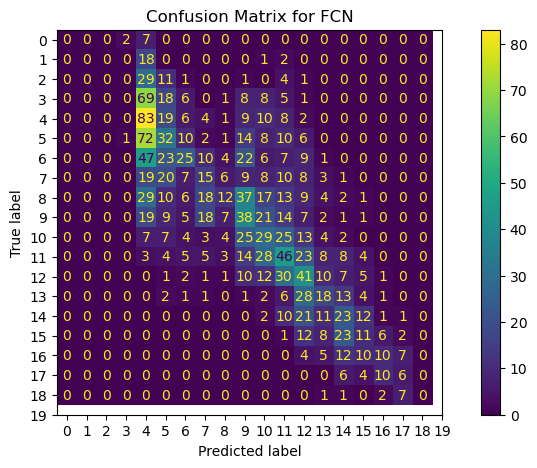

In [339]:
'''final_acc_mean_arrt = np.array([])

num_trials = 5
for i in range(num_trials):
    print(i)
    model_finalt, final_ex1_train_loss_listt, final_ex1_validation_accuracy_listt = train_and_eval(hidden_lays=layers_base, learning_rate=0.001, epochs=50, train_batch_size=train_batch_size, opt='Adam', dropout_prob=0.1, init='KU', batchnorm='yes')
    final_acc_meant, final_acc_stdt = acc_test(model_finalt, test_batch_size=test_batch_size)
    final_acc_mean_arrt = np.append(final_acc_mean_arrt, final_acc_meant)'''

layers_base = [512, 256, 128]
model_final, final_ex1_train_loss_list, final_ex1_validation_accuracy_list = train_and_eval(input=X_features,hidden_lays=layers_base, output=num_cats,learning_rate=1e-5, epochs=100, train_batch_size=train_batch_size, opt='Adam', dropout_prob=0, init='KU', batchnorm='yes')
final_acc_mean, final_acc_std, test_labels_FCN, pred_labels_FCN = acc_test(model_final, test_batch_size=test_batch_size)

fig, ax = plt.subplots(figsize=(10, 5))
ConfusionMatrixDisplay.from_predictions(test_labels_FCN, pred_labels_FCN, ax=ax)
ax.set_xticks(range(len(cat_range))) 
ax.set_yticks(range(len(cat_range)))
ax.xaxis.set_ticklabels(cat_range)
ax.yaxis.set_ticklabels(cat_range)
_ = ax.set_title(
    f"Confusion Matrix for FCN"
)
plt.savefig(f'/Users/jadeg/Documents/UW/winter/AMATH 582/HW5/figures/FCN_class_confmat_split5.png')

In [211]:
print(num_cats)

20


  2%|▏         | 2/100 [00:00<00:17,  5.48it/s]

Epoch: 0; Validation Accuracy:12.704918032786885%
Epoch: 1; Validation Accuracy:8.99077868852459%


  4%|▍         | 4/100 [00:00<00:15,  6.02it/s]

Epoch: 2; Validation Accuracy:6.569020119225037%
Epoch: 3; Validation Accuracy:8.848733233979136%


  6%|▌         | 6/100 [00:01<00:15,  5.91it/s]

...

Epoch: 94; Validation Accuracy:14.565480625931446%
Epoch: 95; Validation Accuracy:14.004284649776451%


 98%|█████████▊| 98/100 [00:12<00:00,  7.24it/s]

Epoch: 96; Validation Accuracy:14.274403874813709%
Epoch: 97; Validation Accuracy:14.544523099850966%


100%|██████████| 100/100 [00:13<00:00,  7.55it/s]

Epoch: 98; Validation Accuracy:14.700540238450074%
Epoch: 99; Validation Accuracy:15.296665424739194%


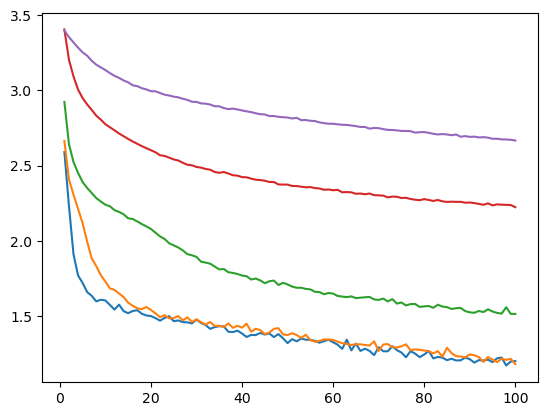

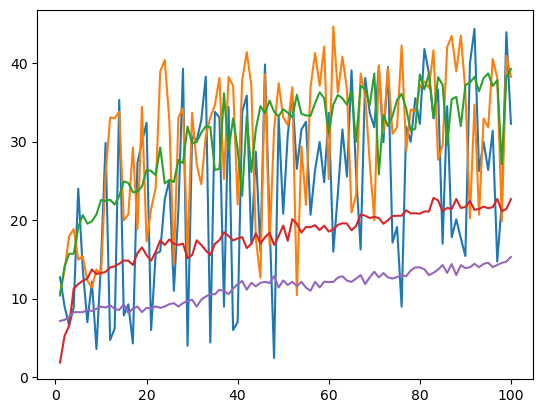

In [340]:
# Initialize the figures before the loop
fig1, ax1 = plt.subplots()
fig2, ax2 = plt.subplots()

lr_arr = [1e-2,1e-3,1e-4,1e-5,1e-6]
epochs = 100

for lr in lr_arr:
    model, train_loss_list, validation_accuracy_list = train_and_eval(input=X_features,hidden_lays=layers_base, output=num_cats,learning_rate=lr, epochs=100, train_batch_size=train_batch_size, opt='Adam', dropout_prob=0, init='KU', batchnorm='yes')

    epochs_vec = range(1,epochs+1)

    # Add a line to the first graph (Training Loss)
    ax1.plot(epochs_vec, train_loss_list, label=f'LR={lr}')
    
    # Add a line to the second graph (Validation Accuracy)
    ax2.plot(epochs_vec, validation_accuracy_list, label=f'LR={lr}')

In [341]:
# Add labels and legends to the first figure
ax1.set_xlabel('Epoch #')
ax1.set_ylabel('Train Loss')
ax1.set_title('Epoch vs. Train Loss')
ax1.legend()

# Add labels and legends to the second figure
ax2.set_xlabel('Epoch #')
ax2.set_ylabel('Validation Accuracy')
ax2.set_title('Epoch vs. Validation Accuracy')
ax2.legend()

fig1.savefig('/Users/jadeg/Documents/UW/winter/AMATH 582/HW5/figures/training_loss_plot.png', dpi=300, bbox_inches='tight')
fig2.savefig('/Users/jadeg/Documents/UW/winter/AMATH 582/HW5/figures/validation_accuracy_plot.png', dpi=300, bbox_inches='tight')

# Show both figures after the loop
plt.show()